# Image Segmenation: SAM

## Get Data

In [ ]:
import kagglehub

path = kagglehub.dataset_download("samanthastaheli/tournamenttourcastholeimages")
print("Path to dataset files:", path)

100%|██████████| 26.5G/26.5G [04:26<00:00, 107MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/samanthastaheli/tournamenttourcastholeimages/versions/1


In [ ]:
import os

image_path = f"{path}/PGAImages/"
images = os.listdir(image_path)
print(images)

['tournament_R2025011_player_34256_hole_13_round_2.png', 'tournament_R2025011_player_34099_hole_14_round_4.png', 'tournament_R2025023_player_33141_hole_17_round_4.png', 'tournament_R2026556_player_47993_hole_4_round_2.png', 'tournament_R2026556_player_34021_hole_3_round_2.png', 'tournament_R2025023_player_29936_hole_1_round_3.png', 'tournament_R2025023_player_35532_hole_14_round_3.png', 'tournament_R2026011_player_47993_hole_2_round_2.png', 'tournament_R2026011_player_49855_hole_17_round_4.png', 'tournament_R2026556_player_48887_hole_14_round_4.png', 'tournament_R2025023_player_34021_hole_7_round_2.png', 'tournament_R2025023_player_32839_hole_17_round_3.png', 'tournament_R2025011_player_33653_hole_9_round_4.png', 'tournament_R2025011_player_34099_hole_18_round_3.png', 'tournament_R2025023_player_25493_hole_4_round_2.png', 'tournament_R2026556_player_34076_hole_10_round_3.png', 'tournament_R2025011_player_36699_hole_13_round_2.png', 'tournament_R2025011_player_47347_hole_18_round_2.png'

### Move subset of images for testing

In [ ]:
import shutil

subset_count = 2
target_dir = "test_folder"
os.makedirs(target_dir, exist_ok=True)

# make sure images to move are actually images
valid_extensions = ('.png', '.jpg', '.jpeg')
images = [f for f in os.listdir(image_path) if f.lower().endswith(valid_extensions)]
images_to_move = images[:subset_count]

# move images using shutil.move
for img in images_to_move:
    src_path = os.path.join(image_path, img)
    dest_path = os.path.join(target_dir, img)
    shutil.move(src_path, dest_path)

print(f"Target folder, {target_dir}, has {len(os.listdir(target_dir))} images")

Target folder, test_folder, has 2 images


## Model

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.6 MB/s eta 0:00:00


In [ ]:
# import torch
# import torch.fx
from ultralytics import SAM

# Load a pre-trained SAM model
model = SAM("sam_b.pt")

# Segment all images in a directory automatically
results = model.predict(
    source=target_dir,
    save=True,          # Saves annotated mask images
    points=[[500, 300]], # Optional: point prompts (x, y) to isolate specific regions
    device="cpu"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/2 /content/test_folder/tournament_R2025011_player_34099_hole_14_round_4.png: 1024x1024 1 0, 29422.6ms
image 2/2 /content/test_folder/tournament_R2025011_player_34256_hole_13_round_2.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 748307.3ms
Speed: 49.7ms preprocess, 388864.9ms inference, 219.5ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/runs/seg

### Results

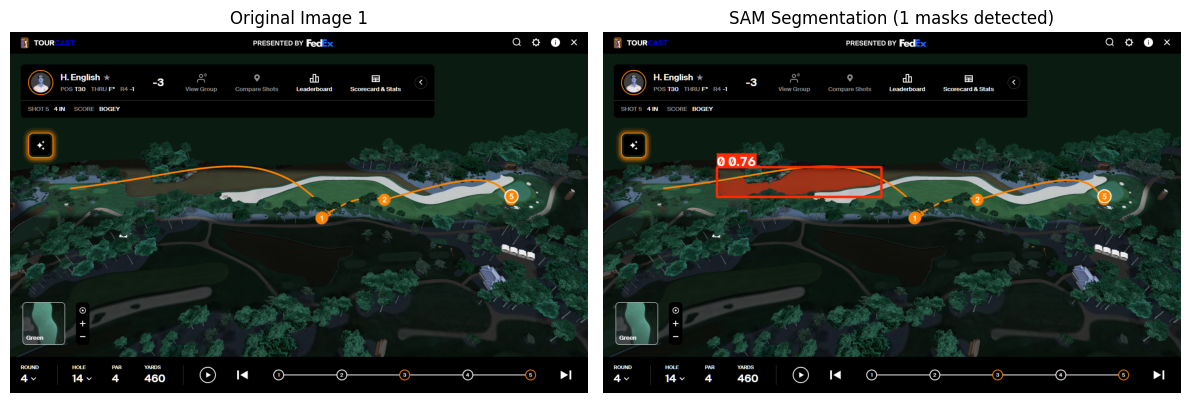

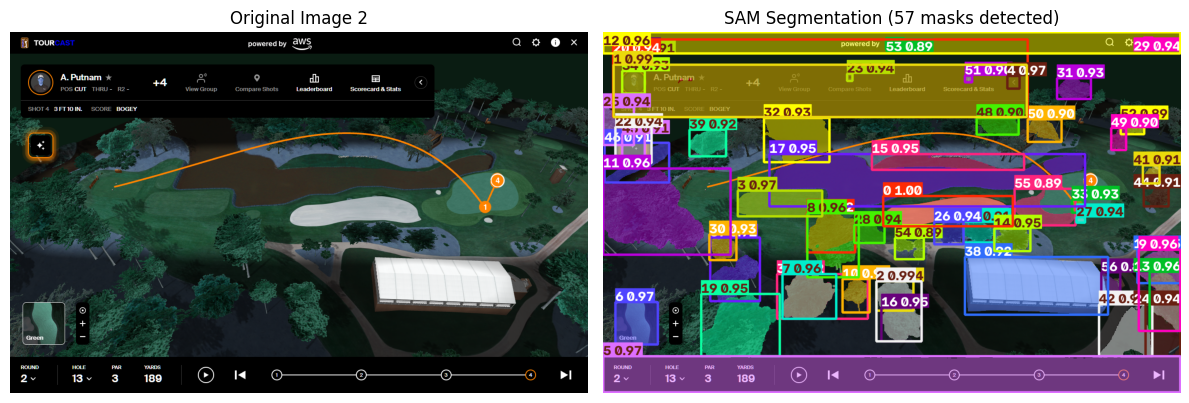

In [ ]:
import matplotlib.pyplot as plt
from ultralytics import SAM

# Iterate through processed images
for i, result in enumerate(results[:3]):  # Display first 3 images
    # 1. Get auto-annotated image from Ultralytics (BGR array)
    annotated_img = result.plot()

    # 2. Plot original vs segmented image using Matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(result.orig_img)
    axes[0].set_title(f"Original Image {i+1}")
    axes[0].axis("off")

    axes[1].imshow(annotated_img)
    axes[1].set_title(f"SAM Segmentation ({len(result.masks)} masks detected)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

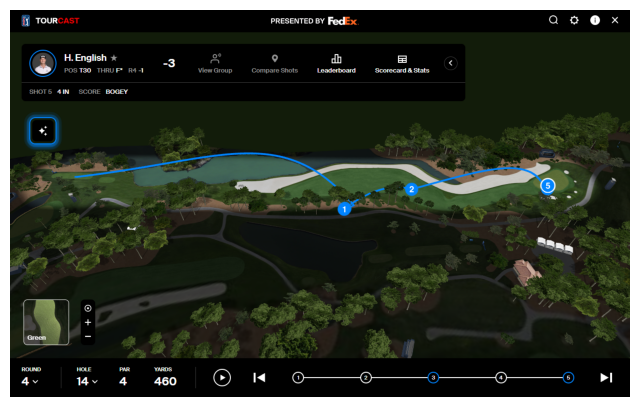

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_custom_masks(result, alpha=0.5):
    img = result.orig_img.copy()

    if result.masks is None:
        return img

    masks = result.masks.data.cpu().numpy()

    for mask in masks:
        # Generate a random color for each detected segment
        color = np.random.randint(0, 255, size=(3,), dtype=np.uint8)

        # Apply color overlay where mask is True
        colored_mask = np.zeros_like(img, dtype=np.uint8)
        colored_mask[mask.astype(bool)] = color

        # Blend the overlay onto the original image
        img = cv2.addWeighted(img, 1.0, colored_mask, alpha, 0)

    return img

# Apply custom overlay to a result
sample_result = results[0]
custom_overlay = apply_custom_masks(sample_result, alpha=0.4)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(custom_overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Train SAM Model

### Create Masks

In [ ]:
import cv2
import numpy as np

# Define exact target RGB color ranges for each class
COLOR_TO_CLASS = {
    # Color (R, G, B) : Class ID
    (231, 25, 31): 1,      # Red (Fairway)
    (250, 255, 0): 2,    # Yellow (Rough)
    (255, 166, 41): 3,    # Orange (Sand)
    (13, 153, 255): 4,    # Blue (Water)
    (151, 71, 255): 5,    # Purple (Trees)
    (20, 174, 92): 6,      # Green (Putting Green)
    (0, 232, 255): 7,    # Cyan (Cart path)
    (255, 0, 214): 8,    # Pink (UI, User Interface)
}

def create_mask(filename):
    # Load colored mask image
    mask_rgb = cv2.imread(filename)
    mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)

    # Initialize output class mask (same H x W, initialized to background = 0)
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)

    # Map each RGB color to its respective class ID
    for color, class_id in COLOR_TO_CLASS.items():
        # Find pixels matching the color (with small tolerance for compression artifacts)
        lower = np.array([max(0, c - 15) for c in color], dtype=np.uint8)
        upper = np.array([min(255, c + 15) for c in color], dtype=np.uint8)

        match = cv2.inRange(mask_rgb, lower, upper)
        class_mask[match > 0] = class_id

    # Save as a single-channel grayscale PNG mask (values 0, 1, 2, ...)
    cv2.imwrite(f"mask_{filename.replace('.png', '')}.png", class_mask)
    print("Conversion complete! Class mask saved.")

segmented_files = glob.glob("segmented_*")

for file in segmented_files:
    create_mask(file)

Conversion complete! Class mask saved.
Conversion complete! Class mask saved.


### Dataset

In [ ]:
# Set up files like this:

# dataset/
# ├── images/
# │   ├── img1.jpg
# │   └── img2.jpg
# └── masks/
#     ├── img1.png  # Binary mask (0 = background, 255 = target)
#     └── img2.png

import os
import shutil
import glob

# Make folders
os.makedirs("dataset/images", exist_ok=True)
os.makedirs("dataset/masks", exist_ok=True)

# Move images and masks to folders
tournament_files = glob.glob("tournament_*")
print(tournament_files)
mask_files = glob.glob("mask_*")
print(mask_files)

for file in tournament_files:
    shutil.move(file, "dataset/images")

for file in mask_files:
    shutil.move(file, "dataset/masks")

['tournament_R2026011_player_46046_hole_17_round_4.png', 'tournament_R2026011_player_46046_hole_16_round_4.png']
['mask_segmented_tournament_R2026011_player_46046_hole_17_round_4.png', 'mask_segmented_tournament_R2026011_player_46046_hole_16_round_4.png']


In [ ]:
!pip install segment_anything

In [ ]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

class CustomSAMDataset(Dataset):
    def __init__(self, img_dir, mask_dir, sam_model):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        self.transform = ResizeLongestSide(sam_model.image_encoder.img_size)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Read image and mask
        image = cv2.imread(self.img_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 128).astype(np.float32)  # Binary mask 0.0 or 1.0

        # Transform image to SAM input size
        input_image = self.transform.apply_image(image)
        input_image_torch = torch.as_tensor(input_image).permute(2, 0, 1).contiguous()

        return input_image_torch, torch.as_tensor(mask).unsqueeze(0)

In [ ]:
import urllib.request

# Define weight file path and download URL
checkpoint_filename = "sam_vit_b_01ec64.pth"
checkpoint_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"

# Download the model weight file automatically if not present
if not os.path.exists(checkpoint_filename):
    print("Downloading SAM ViT-B checkpoint...")
    urllib.request.urlretrieve(checkpoint_url, checkpoint_filename)
    print("Download complete!")

# Load Pretrained SAM Weights
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

# Freeze Encoders, Train ONLY Mask Decoder
for param in sam.image_encoder.parameters():
    param.requires_grad = False
for param in sam.prompt_encoder.parameters():
    param.requires_grad = False

sam.mask_decoder.train()

optimizer = torch.optim.Adam(sam.mask_decoder.parameters(), lr=1e-4, weight_decay=1e-4)
bce_loss = nn.BCEWithLogitsLoss()

dataset = CustomSAMDataset("dataset/images", "dataset/masks", sam)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

### Training Loop

In [ ]:
print("Starting SAM Mask Decoder Fine-Tuning...")
for epoch in range(20):  # 20 epochs is usually sufficient for fine-tuning
    epoch_loss = 0.0
    for images, masks in dataloader:
        images, masks = images.to(device), masks.to(device)

        with torch.no_grad():
            # Preprocess image and generate image embedding
            prep_images = sam.preprocess(images)
            image_embeddings = sam.image_encoder(prep_images)

            # Use empty prompts or bounding box bounds
            sparse_embeddings, dense_embeddings = sam.prompt_encoder(
                points=None, boxes=None, masks=None
            )

        # Predict mask through trainable decoder
        low_res_masks, _ = sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        # Upsample mask to original resolution
        pred_masks = sam.postprocess_masks(low_res_masks, input_size=(1024, 1024), original_size=masks.shape[-2:])

        # Calculate Loss
        loss = bce_loss(pred_masks, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/20 - Loss: {epoch_loss/len(dataloader):.4f}")

# Save fine-tuned mask decoder
torch.save(sam.mask_decoder.state_dict(), "sam_custom_mask_decoder.pth")

Starting SAM Mask Decoder Fine-Tuning...
Epoch 1/20 - Loss: 0.0001
Epoch 2/20 - Loss: 0.0000
Epoch 3/20 - Loss: 0.0000
Epoch 4/20 - Loss: 0.0000
Epoch 5/20 - Loss: 0.0000
Epoch 6/20 - Loss: 0.0000
Epoch 7/20 - Loss: 0.0000
Epoch 8/20 - Loss: 0.0000
Epoch 9/20 - Loss: 0.0000
Epoch 10/20 - Loss: 0.0000
Epoch 11/20 - Loss: 0.0000
Epoch 12/20 - Loss: 0.0000
Epoch 13/20 - Loss: 0.0000
Epoch 14/20 - Loss: 0.0000
Epoch 15/20 - Loss: 0.0000
Epoch 16/20 - Loss: 0.0000
Epoch 17/20 - Loss: 0.0000
Epoch 18/20 - Loss: 0.0000
Epoch 19/20 - Loss: 0.0000
Epoch 20/20 - Loss: 0.0000


### Test New Model

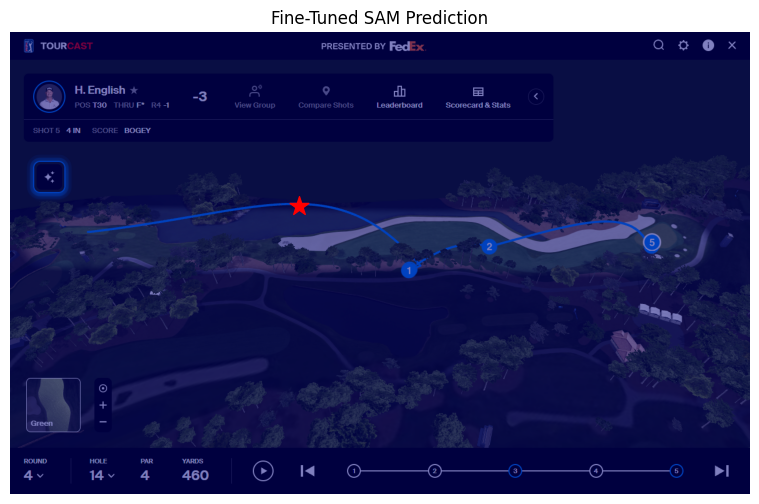

In [ ]:
from segment_anything import SamPredictor

# Load fine-tuned mask decoder weights
custom_weights_path = "sam_custom_mask_decoder.pth"
sam.mask_decoder.load_state_dict(torch.load(custom_weights_path, map_location=device))
sam.to(device)

predictor = SamPredictor(sam)

# Run inference on a test image
image_path = "test_folder/tournament_R2025011_player_34099_hole_14_round_4.png"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image_rgb)

# Pass a prompt point (e.g., x=500, y=300)
input_point = np.array([[500, 300]])
input_label = np.array([1])  # 1 = foreground point prompt

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=False,
)

# Visualize the prediction
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.imshow(masks[0], alpha=0.5, cmap="jet")  # Overlay predicted mask
plt.scatter(input_point[:, 0], input_point[:, 1], color="red", marker="*", s=200) # Plot point prompt
plt.title("Fine-Tuned SAM Prediction")
plt.axis("off")
plt.show()